In [1]:
# create a torch nn to compare the transformer to:
import torch
import numpy as np

In [2]:
from dataset import Dataset,Track
np_rng = np.random.default_rng(42)
batch_size = 120
context_length = 32

# this code will only load the train sets if they are not already defined
# be cautious when changing parameters and re-runing this cell without restarting the jupyter kernel
try:
    print(type(train_set))
except:    
    train_set = Dataset("train", data_dir="../../data",context_length=context_length,uniform=True)
    validation_set = Dataset("val", data_dir="../../data", context_length=context_length, uniform=True)

def get_batch(set_name="train"):
        if set_name == "train":
            return train_set.get_batch_from_slices(batch_size, np_rng)
        if set_name == "val":
            return validation_set.get_batch_from_slices(batch_size, np_rng)

In [3]:
from torch import nn


class PureNnMidiClass(nn.Module):
    def __init__(self, context_length: int, num_classes: int, p_drop: float = 0.1):
        super().__init__()
        context_length_squred = context_length * context_length  # 32 * 32 = 1024
        self.components = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(context_length, context_length_squred),
            nn.Dropout(p_drop),
            nn.ReLU(),
            nn.Linear(context_length_squred, context_length_squred),
            nn.Dropout(p_drop),
            nn.ReLU(),
            nn.Linear(context_length_squred, context_length),
            nn.ReLU(),
            nn.Linear(context_length, num_classes),
        )

    def forward(self, x):
        logits = self.components.forward(x)
        return logits


model = PureNnMidiClass(context_length, 3).to(device="cuda")

In [30]:
for lr in [1e-4,1e-5,1e-6]:
    optim = torch.optim.AdamW(model.parameters(),lr=lr) 
    for iteration in range(10_000):
        batch= get_batch("train")
        x,y = batch
        x=torch.tensor(x,device="cuda",dtype=torch.float32)
        y=torch.tensor(y,device="cuda") 
        logits = model.forward(x)
        loss = nn.functional.cross_entropy(logits,y)
        model.zero_grad()
        loss.backward()
        optim.step()
        if iteration % 100 == 0:
            print(f"iteration: {iteration} and loss: {loss.item()}")




iteration: 0 and loss: 0.7992393374443054
iteration: 100 and loss: 0.7588966488838196
iteration: 200 and loss: 0.7111229300498962
iteration: 300 and loss: 0.8281380534172058
iteration: 400 and loss: 0.7075623273849487
iteration: 500 and loss: 0.7255274653434753
iteration: 600 and loss: 0.7677255868911743
iteration: 700 and loss: 0.8188480138778687
iteration: 800 and loss: 0.8248618245124817
iteration: 900 and loss: 0.8288477659225464
iteration: 1000 and loss: 0.9023718237876892
iteration: 1100 and loss: 0.8316639065742493
iteration: 1200 and loss: 0.8037980198860168
iteration: 1300 and loss: 0.8783641457557678
iteration: 1400 and loss: 0.7418575286865234
iteration: 1500 and loss: 0.7768926024436951
iteration: 1600 and loss: 0.8721859455108643
iteration: 1700 and loss: 0.8158944845199585
iteration: 1800 and loss: 0.8317827582359314
iteration: 1900 and loss: 0.8318606019020081
iteration: 2000 and loss: 0.7455571293830872
iteration: 2100 and loss: 0.7691876292228699
iteration: 2200 and lo

In [31]:
hits = 0
val_iters = 100
with torch.no_grad():
    for _ in range(val_iters):
        x, y = get_batch("val")
        x = torch.tensor(x,device="cuda",dtype=torch.float32)
        y = torch.tensor(y,device="cuda")
        logits = model.forward(x)
        model_preds = logits.argmax(-1)
        hits+=((model_preds==y).sum())
total_preds = val_iters * batch_size
print(hits/total_preds * 100)# give percentage

# ca 50% with context len 32 and 60% with 64

tensor(61.7000, device='cuda:0')


In [32]:
pnn_accuracy = hits/total_preds * 100

In [7]:
# REDifine if you want to change the context_length for example
from dataset import Dataset,Track
np_rng = np.random.default_rng(42)
batch_size = 120
context_length = 32

# this code will only load the train sets if they are not already defined
# be cautious when changing parameters and re-runing this cell without restarting the jupyter kernel
try:
    print(type(train_set))
except:    
    train_set = Dataset("train", data_dir="../../data",context_length=context_length,uniform=True)
    validation_set = Dataset("val", data_dir="../../data", context_length=context_length, uniform=True)

def get_batch(set_name="train"):
        if set_name == "train":
            return train_set.get_batch_from_slices(batch_size, np_rng)
        if set_name == "val":
            return validation_set.get_batch_from_slices(batch_size, np_rng)

<class 'dataset.Dataset'>


In [8]:
from torch import nn


class ConvNN(nn.Module):
    def __init__(self, context_length: int, num_classes: int, p_drop: float = 0.1):
        super().__init__()
        context_length_squred = context_length * context_length  # 32 * 32 = 1024

        self.components = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Conv1d(1,32,5,1),
            nn.Dropout(p_drop),
            nn.Conv1d(32,64,5,1),
            nn.MaxPool1d(2,2),
            nn.Conv1d(64,128,3,1),
            nn.Conv1d(128,256,10),
            nn.Flatten(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(1024, context_length),
            nn.ReLU(),
            nn.Linear(context_length, num_classes),
        )

    def forward(self, x):
        logits = self.components.forward(x)
        return logits


c_model = ConvNN(context_length, 3).to(device="cuda")

In [33]:
for lr in [1e-4,1e-5,1e-6]:
    optim = torch.optim.AdamW(c_model.parameters(),lr=lr) 
    for iteration in range(5000):
        batch= get_batch("train")
        x,y = batch
        x=torch.tensor(x,device="cuda",dtype=torch.float32).reshape((batch_size,1,context_length))
        y=torch.tensor(y,device="cuda") 
        logits = c_model.forward(x)
        loss = nn.functional.cross_entropy(logits,y)
        c_model.zero_grad()
        loss.backward()
        optim.step()
        if iteration % 100 == 0:
            print(f"iteration: {iteration} and loss: {loss.item()}")




iteration: 0 and loss: 0.7274605631828308
iteration: 100 and loss: 0.7746899127960205
iteration: 200 and loss: 0.7057783603668213
iteration: 300 and loss: 0.7615835070610046
iteration: 400 and loss: 0.7859328389167786
iteration: 500 and loss: 0.7806466817855835
iteration: 600 and loss: 0.7700355052947998
iteration: 700 and loss: 0.8663281202316284
iteration: 800 and loss: 0.7734827399253845
iteration: 900 and loss: 0.7322353720664978
iteration: 1000 and loss: 0.7033379673957825
iteration: 1100 and loss: 0.7998613119125366
iteration: 1200 and loss: 0.7914257049560547
iteration: 1300 and loss: 0.7566888332366943
iteration: 1400 and loss: 0.7241494059562683
iteration: 1500 and loss: 0.7381755113601685
iteration: 1600 and loss: 0.7432209849357605
iteration: 1700 and loss: 0.7691325545310974
iteration: 1800 and loss: 0.7629926800727844
iteration: 1900 and loss: 0.8193666934967041
iteration: 2000 and loss: 0.7488782405853271
iteration: 2100 and loss: 0.6891739368438721
iteration: 2200 and lo

In [34]:
hits = 0
val_iters = 100
with torch.no_grad():
    for _ in range(val_iters):
        x, y = get_batch("val")
        x = torch.tensor(x,device="cuda",dtype=torch.float32).reshape((batch_size,1,context_length))
        y = torch.tensor(y,device="cuda")
        logits = c_model.forward(x)
        model_preds = logits.argmax(-1)
        hits+=((model_preds==y).sum())
total_preds = val_iters * batch_size
cnn_accuracy = hits/total_preds * 100
print(cnn_accuracy)# give percentage

# ca 60% with context len 32

tensor(62.2000, device='cuda:0')


In [35]:
x, y = get_batch("val")
print(x.shape)

(120, 32)


(0.0, 100.0)

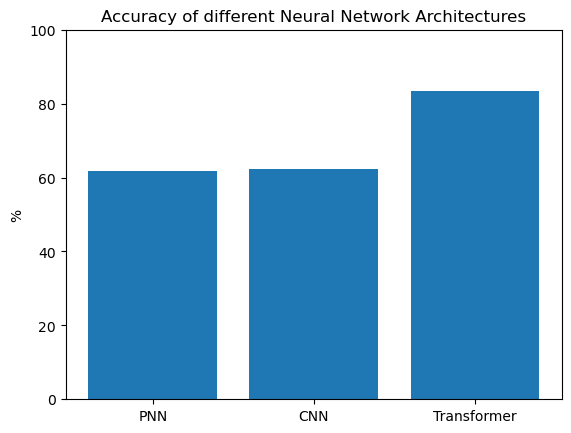

In [37]:
# plot cnn, pnn and transformer.
transformer_accuracy = 83.3833 # from a run 
import matplotlib.pyplot as plt
plt.bar(["PNN","CNN","Transformer"],[pnn_accuracy.item(),cnn_accuracy.item(),transformer_accuracy])
plt.title("Accuracy of different Neural Network Architectures")
plt.ylabel("%")
plt.ylim(0,100)

In [13]:
import matplotlib.pyplot as plt
import os
data_dir = "../../data"
name = "train"
only_genres = None # use all genres in the data folder
if not os.path.exists(os.path.join(data_dir, "tokenized", name)):
    raise FileNotFoundError(f"Dataset {name} not found")

_genres = os.listdir(os.path.join(data_dir, "tokenized", name))
genres = list()

for genre in _genres:
    if genre.startswith("GENRE_"):
        if only_genres is not None and genre[6:] not in only_genres:
            continue
        genres.append(genre[6:])

genres = sorted(genres)

_genres_to_idx = {}
for i, genre in enumerate(genres):
    _genres_to_idx[genre] = i

tracks = {}

for genre in genres:
    tracks[genre] = []
    for file in os.listdir(
        os.path.join(data_dir, "tokenized", name, f"GENRE_{genre}")
    ):
        if file.endswith(".bin"):
            track = Track(file[:-4], genre, name)
            if track.exists(data_dir=data_dir):
                tracks[genre].append(track)
            else:
                print(f"File {file} not found")
                #raise FileNotFoundError(f"Tokenized file {file} not found")
        


In [14]:
total_token_distribution= {}
tokens_per_class = {}
for genre in genres:
    total_token_distribution[genre]=np.zeros((483,))
    tokens_per_class[genre]=0
    for track in tracks[genre]:
        track = track.get_memmap(data_dir=data_dir)
        np.add.at(total_token_distribution[genre],track,1)
        tokens_per_class[genre]+=track.shape[0]

{'classical': 29026221, 'pop': 63285502, 'rock': 79744441}


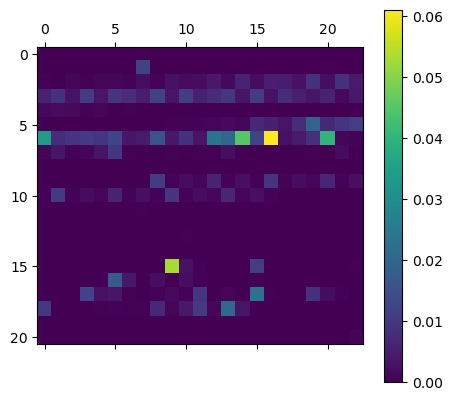

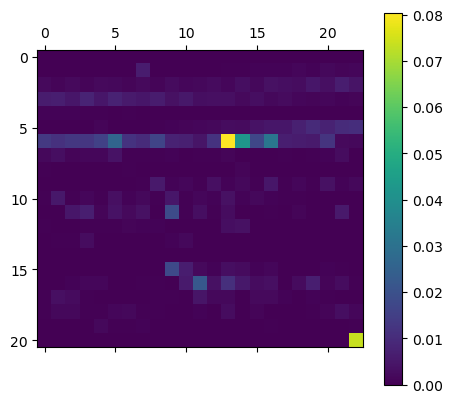

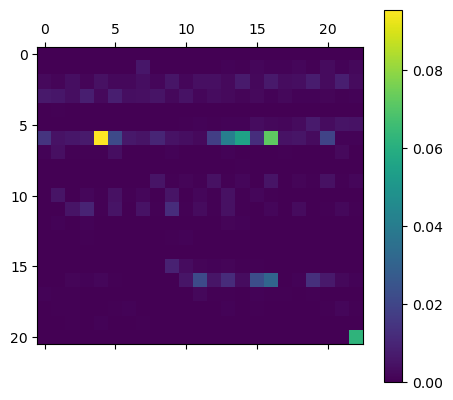

In [15]:
print(tokens_per_class)
#print(total_token_distribution)

all_genres_matrix = np.stack([distri.reshape((21,23))/tokens_per_class[genre] for genre,distri in total_token_distribution.items()])
for index in range(all_genres_matrix.shape[0]):
    plt.matshow(all_genres_matrix[index])
    plt.colorbar()
    